# 描述性统计与可视化

本 Notebook 对应作业第四部分：

- 4.1 计算 10 只股票日收益率的描述性统计
- 4.2 完成图1-图4必做可视化（图5选做）
- 所有图形保存至 `output/`，并确保分辨率不低于 150 dpi

## 环境准备与中文字体设置

本节完成依赖导入、路径设置，并配置 Matplotlib 中文字体，确保图中的中文标题与注释正常显示。

In [7]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, pearsonr
from matplotlib import font_manager, rcParams

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 中文字体设置：优先使用常见中文字体，避免图中中文乱码
font_candidates = [
    "PingFang SC", "Hiragino Sans GB", "Heiti SC", "STHeiti",
    "SimHei", "Microsoft YaHei", "Arial Unicode MS"
]
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in available_fonts), None)

if selected_font:
    rcParams["font.sans-serif"] = [selected_font]
else:
    rcParams["font.sans-serif"] = ["DejaVu Sans"]

rcParams["axes.unicode_minus"] = False
print("已设置字体:", rcParams["font.sans-serif"][0])

已设置字体: Hiragino Sans GB


## 数据读取与收益率准备

读取清洗后的数据，构建股票收益率表、行业映射表与指数序列，为统计和可视化做准备。

In [8]:
stock = pd.read_csv(DATA_DIR / "clean" / "stock_clean.csv")
combined = pd.read_csv(DATA_DIR / "combined" / "combined_data.csv")

stock["date"] = pd.to_datetime(stock["date"], errors="coerce")
stock["code"] = stock["code"].astype(str).str.zfill(6)
stock = stock.dropna(subset=["date", "code", "close"]).copy()
stock = stock.sort_values(["code", "date"])

# 作业要求使用对数收益率
stock["log_ret"] = np.log(stock["close"] / stock.groupby("code")["close"].shift(1))

stock_info = stock[["code", "name", "industry"]].drop_duplicates(subset=["code"])
code_to_name = dict(zip(stock_info["code"], stock_info["name"]))
code_to_industry = dict(zip(stock_info["code"], stock_info["industry"]))

# 构造收益率宽表（用于相关性和后续回归）
ret_wide = stock.pivot_table(index="date", columns="code", values="log_ret")

print("stock shape:", stock.shape)
print("ret_wide shape:", ret_wide.shape)
stock.head(3)

stock shape: (14590, 13)
ret_wide shape: (1514, 10)


,date,open,close,high,low,volume,amount,code,name,industry,daily_ret,is_extreme,log_ret
0,2020-01-02,4530.67,4497.51,4641.17,4490.61,101213040.0,3.342374e+09,000002,万科A,房地产,NaN,False,NaN
1,2020-01-03,4518.23,4427.07,4532.05,4389.77,80553629.0,2.584310e+09,000002,万科A,房地产,-0.015662,False,-0.015786
2,2020-01-06,4385.63,4352.48,4387.01,4316.56,87684058.0,2.761449e+09,000002,万科A,房地产,-0.016849,False,-0.016992


## 清洗说明（02_clean.ipynb）


- 缺失值与异常值处理：对关键价格字段做缺失检查，按代码排序后进行必要填补；对单日涨跌幅超阈值样本进行离群标注（不直接删除）。
- 类型与主键一致性：统一 `date` 为 `datetime`、`code` 为 6 位字符串，保证与指数、宏观、财务表的合并键一致。
- 去重与频率处理：去除重复记录；日频行情与月频宏观数据采用月末对齐或按月映射，避免频率错配造成伪相关。
- 合并口径：以股票日频表为主，采用 left join 合并指数与宏观信息，确保个股样本连续性。
- 数据完整性提示：财务 ROE 已按最近 5 个完整年度（2021-2025）重建，但贵州茅台 2025 年值在源接口缺失，该缺口在图 5 解读中单独说明。

## 4.1 基本统计量

本节计算 10 只股票日对数收益率的核心统计指标：

- 年化均值（`mean * 252`）
- 年化波动率（`std * sqrt(252)`）
- 偏度、峰度
- 最大回撤（基于收盘价序列计算）

In [10]:
def max_drawdown(price_series: pd.Series) -> float:
    s = price_series.dropna()
    if s.empty:
        return np.nan
    nav = s / s.iloc[0]
    dd = nav / nav.cummax() - 1
    return dd.min()

rows = []
for code, g in stock.groupby("code"):
    r = g["log_ret"].dropna()
    rows.append({
        "股票": code_to_name.get(code, code),
        "行业": code_to_industry.get(code, "未知"),
        "年化均值": r.mean() * 252,
        "年化波动率": r.std() * np.sqrt(252),
        "偏度": r.skew(),
        "峰度": r.kurt(),
        "最大回撤": max_drawdown(g.sort_values("date")["close"]),
    })

stats_df = pd.DataFrame(rows).sort_values(["行业", "股票"]).reset_index(drop=True)

stats_show = stats_df.copy()
for c in ["年化均值", "年化波动率", "偏度", "峰度", "最大回撤"]:
    stats_show[c] = stats_show[c].map(lambda x: f"{x:.4f}" if pd.notna(x) else "")

display(stats_show)

# 保存统计表
stats_df.to_csv(OUTPUT_DIR / "desc_stats.csv", index=False, encoding="utf-8-sig")
print("已保存: output/desc_stats.csv")

,股票,行业,年化均值,年化波动率,偏度,峰度,最大回撤
0,万科A,房地产,-0.3234,0.3638,0.6562,3.2719,-0.8657
1,广汽集团,汽车,-0.0716,0.3709,0.5455,3.3966,-0.6320
2,比亚迪,汽车,0.3060,0.4330,0.3040,2.0914,-0.5254
3,顺丰控股,物流,0.0158,0.3246,0.3759,3.5340,-0.7077
4,贵州茅台,白酒,0.0642,0.2770,0.2629,3.6141,-0.4748
5,中国海油,能源,0.3448,0.3515,0.3530,3.7623,-0.3109
6,中国石油,能源,0.1751,0.2926,0.2263,5.1463,-0.3254
7,中兴通讯,通讯,-0.0019,0.4261,0.3092,2.4817,-0.6187
8,工商银行,银行,0.0927,0.1631,0.4546,5.7904,-0.2017
9,招商银行,银行,0.0468,0.2773,0.2647,3.1519,-0.5094


已保存: output/desc_stats.csv


## 4.2 图 1：归一化收盘价走势图（含沪深300）

做法说明：

- 对每只股票用首个有效交易日收盘价归一化到 1
- 沪深300同样归一化后叠加
- 颜色按行业映射，图例中体现股票与行业信息

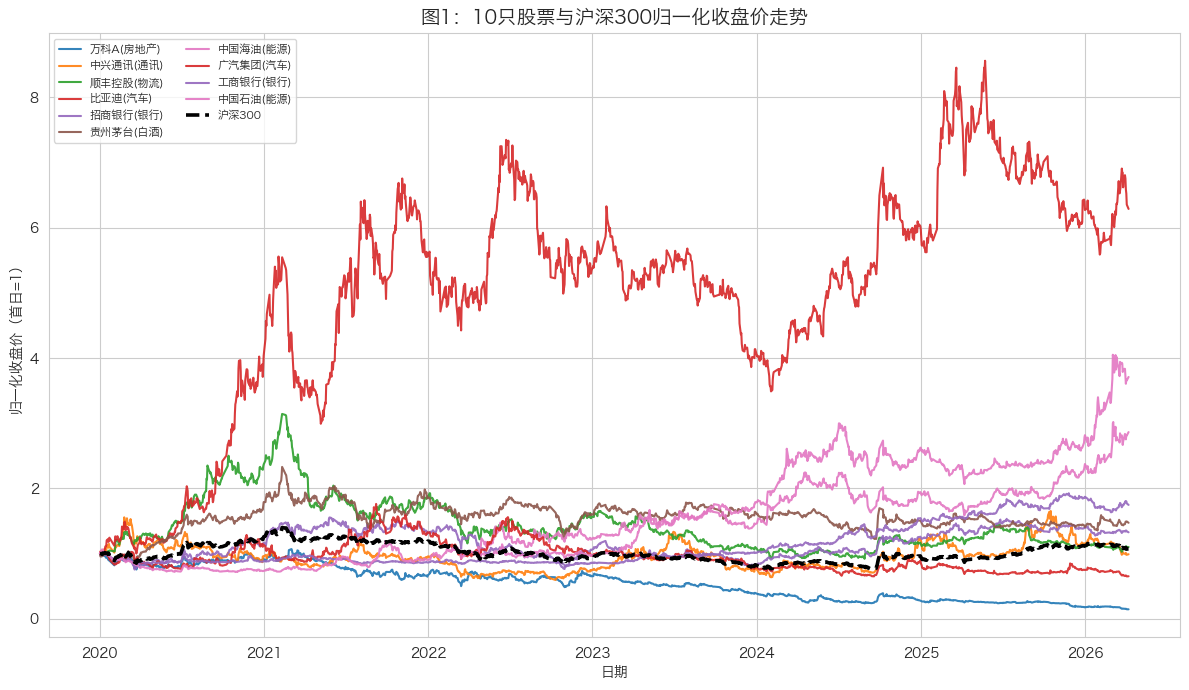

In [9]:
industry_order = stock_info[["industry"]].drop_duplicates()["industry"].tolist()
palette = sns.color_palette("tab10", n_colors=max(10, len(industry_order)))
industry_color = {ind: palette[i] for i, ind in enumerate(industry_order)}

fig, ax = plt.subplots(figsize=(12, 7))

for code, g in stock.groupby("code"):
    g = g.sort_values("date")
    base = g["close"].dropna().iloc[0]
    if pd.isna(base) or base == 0:
        continue
    y = g["close"] / base
    ind = code_to_industry.get(code, "未知")
    ax.plot(g["date"], y, color=industry_color.get(ind, "gray"), alpha=0.9,
            label=f"{code_to_name.get(code, code)}({ind})")

# 叠加沪深300
idx300 = pd.read_csv(DATA_DIR / "index" / "index_000300.csv")
idx300["日期"] = pd.to_datetime(idx300["日期"], errors="coerce")
idx300 = idx300.dropna(subset=["日期", "收盘价"]).sort_values("日期")
idx300_norm = idx300["收盘价"] / idx300["收盘价"].iloc[0]
ax.plot(idx300["日期"], idx300_norm, color="black", linewidth=2.6, linestyle="--", label="沪深300")

ax.set_title("图1：10只股票与沪深300归一化收盘价走势", fontsize=14)
ax.set_xlabel("日期")
ax.set_ylabel("归一化收盘价（首日=1）")

# 去重图例
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), fontsize=8, ncol=2, loc="upper left", frameon=True)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig1_normalized_price.png", dpi=180)
plt.show()

图 1 解读：

- 从归一化走势看，不同行业股票在样本期内呈现明显分化，说明行业属性与个股基本面共同影响长期收益路径。
- 与沪深300相比，部分个股在某些阶段表现出更高弹性，也意味着其波动与风险暴露可能更大。
- 将行业信息映射到图例后，可以更直观地观察同一行业内部与跨行业之间的走势差异。

## 图 2：日收益率分布图（2×5 分面 + 正态曲线）

做法说明：

- 对 10 只股票分别绘制日对数收益率直方图
- 叠加同均值与标准差的正态密度曲线
- 每个子图标注均值与标准差

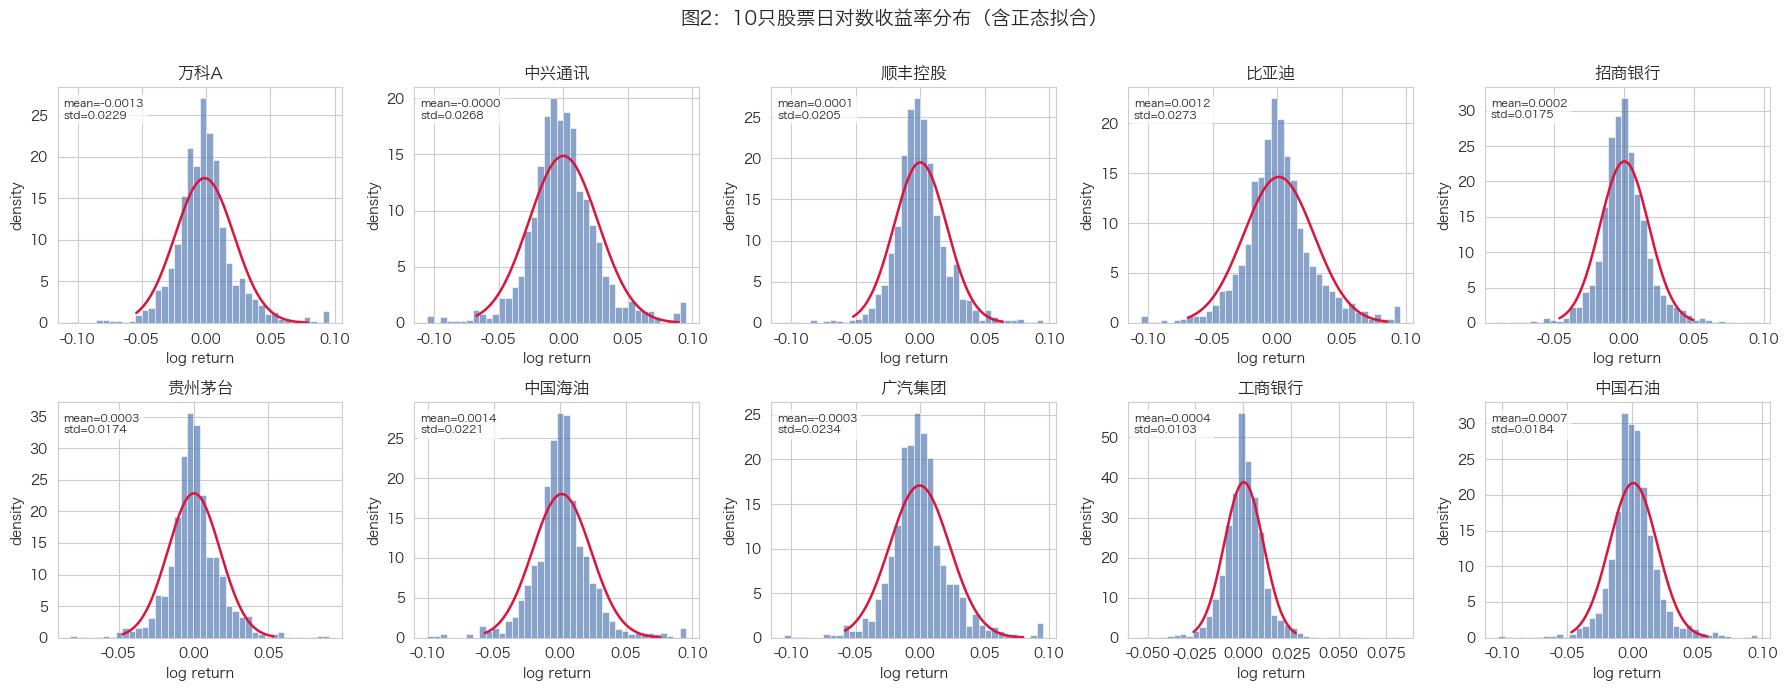

In [5]:
codes_sorted = sorted(stock_info["code"].unique())
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=False, sharey=False)
axes = axes.flatten()

for i, code in enumerate(codes_sorted):
    ax = axes[i]
    r = stock.loc[stock["code"] == code, "log_ret"].dropna()

    sns.histplot(r, bins=40, stat="density", color="#4C72B0", alpha=0.65, ax=ax)

    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.quantile(0.01), r.quantile(0.99), 200)
    ax.plot(x, norm.pdf(x, mu, sigma), color="crimson", lw=1.8)

    ax.set_title(f"{code_to_name.get(code, code)}")
    ax.text(0.02, 0.95, f"mean={mu:.4f}\nstd={sigma:.4f}", transform=ax.transAxes,
            va="top", fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.set_xlabel("log return")
    ax.set_ylabel("density")

fig.suptitle("图2：10只股票日对数收益率分布（含正态拟合）", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUTPUT_DIR / "fig2_return_distribution.png", dpi=180)
plt.show()

图 2 解读：

- 各股票收益率分布普遍表现出“尖峰厚尾”特征，说明极端波动事件发生概率高于标准正态分布假设。
- 不同股票的均值与波动率差异明显，反映了行业属性和个股经营周期对风险收益特征的影响。
- 正态曲线与经验分布在尾部的偏离，为后续风险管理（如 VaR、尾部风险评估）提供了依据。

## 图 3：收益率相关系数热力图

做法说明：

- 先计算 10 只股票日对数收益率相关系数矩阵
- 再按行业排序代码，观察同行业与跨行业相关性的差异
- 热力图中标注具体相关系数数值

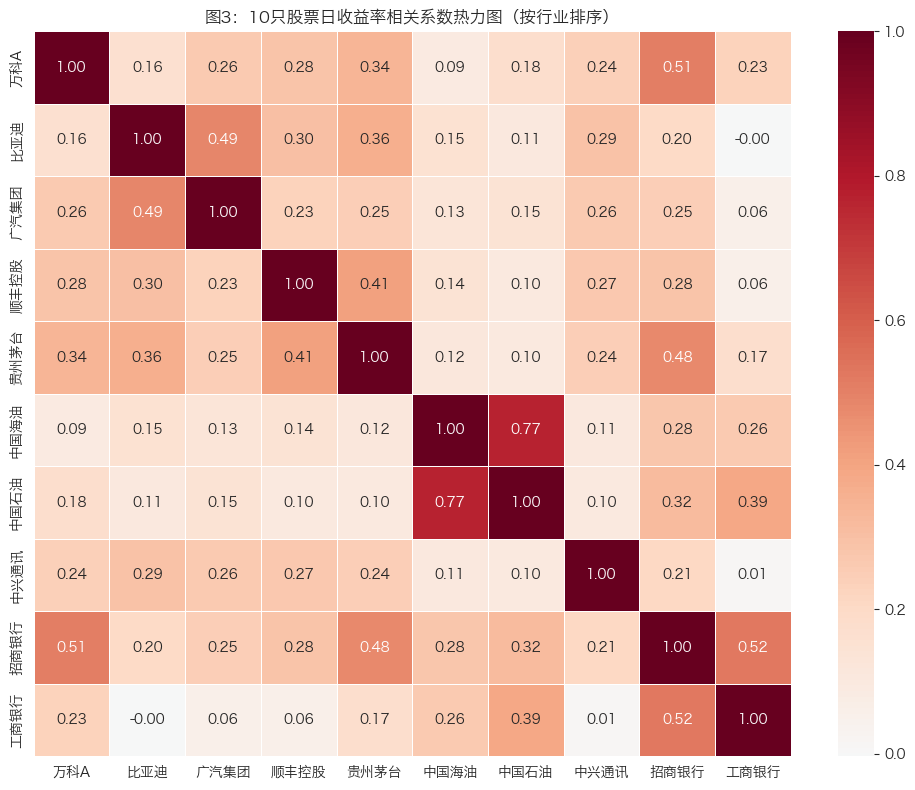

In [6]:
order_df = stock_info.copy()
order_df["industry_order"] = order_df["industry"].astype(str)
order_df = order_df.sort_values(["industry_order", "code"])
ordered_codes = order_df["code"].tolist()

corr = ret_wide[ordered_codes].corr()
name_labels = [code_to_name.get(c, c) for c in ordered_codes]
corr.index = name_labels
corr.columns = name_labels

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("图3：10只股票日收益率相关系数热力图（按行业排序）")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig3_corr_heatmap.png", dpi=180)
plt.show()

图 3 解读：

- 整体上看，多数股票之间相关系数为正，说明市场系统性因素（宏观流动性、风险偏好）对个股收益有共同驱动。
- 若同一行业内部的相关系数普遍更高，通常意味着行业景气、政策冲击和成本结构相近导致联动更强。
- 跨行业较低相关性有助于分散化配置，后续可据此讨论资产组合的风险分散效果。

## 图 4：宏观指标与沪深300月度收益率关系（CPI）

做法说明：

- 将沪深300日度收盘价转换为月末收盘并计算月度对数收益率
- 将 CPI 月度同比与同月沪深300收益率对齐
- 绘制散点图并拟合线性趋势线，同时标注 Pearson 相关系数

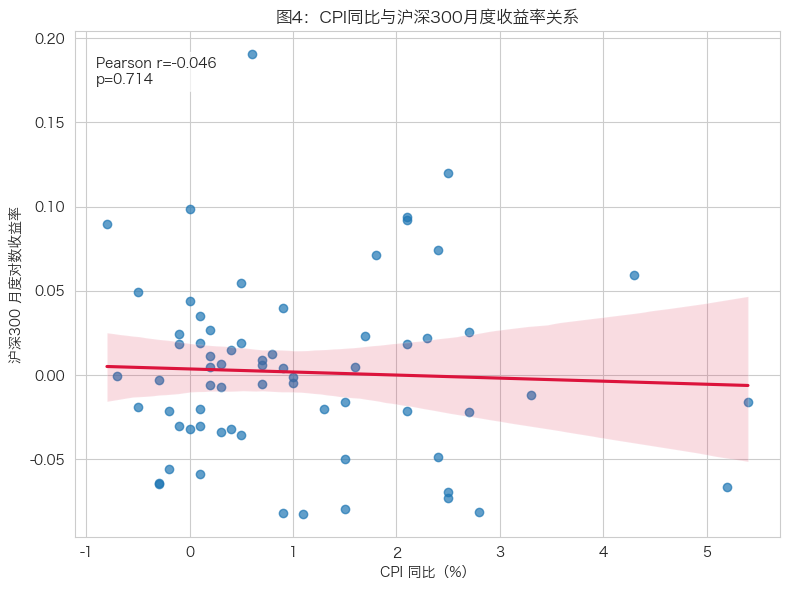

,hs300_ret_m,cpi_yoy
日期,,
2020-02-29,-0.016076,5.4
2020-03-31,-0.066609,5.2
2020-04-30,0.059612,4.3
2020-05-31,-0.011711,3.3
2020-06-30,0.073983,2.4


In [9]:
# 沪深300月度收益率
idx300 = pd.read_csv(DATA_DIR / "index" / "index_000300.csv")
idx300["日期"] = pd.to_datetime(idx300["日期"], errors="coerce")
idx300 = idx300.dropna(subset=["日期", "收盘价"]).sort_values("日期")

idx_m = idx300.set_index("日期")["收盘价"].resample("M").last().dropna()
idx_ret_m = np.log(idx_m / idx_m.shift(1)).dropna().rename("hs300_ret_m")

# CPI 月度同比（兼容多种列名）
cpi = pd.read_csv(DATA_DIR / "macro" / "macro_cpi.csv")
date_col = next((c for c in ["日期", "date", "月份", "时间"] if c in cpi.columns), None)
val_col = next((c for c in ["同比", "今值", "cpi_yoy", "value"] if c in cpi.columns), None)
if date_col is None or val_col is None:
    raise ValueError(f"macro_cpi.csv 列名不匹配，当前列: {list(cpi.columns)}")

cpi[date_col] = pd.to_datetime(cpi[date_col], errors="coerce")
cpi[val_col] = pd.to_numeric(cpi[val_col], errors="coerce")
cpi_m = (
    cpi.dropna(subset=[date_col, val_col])
       .set_index(date_col)[val_col]
       .resample("M").last()
       .rename("cpi_yoy")
)

# 对齐
macro_vs_mkt = pd.concat([idx_ret_m, cpi_m], axis=1).dropna()
r, p = pearsonr(macro_vs_mkt["cpi_yoy"], macro_vs_mkt["hs300_ret_m"])

fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(
    data=macro_vs_mkt,
    x="cpi_yoy",
    y="hs300_ret_m",
    scatter_kws={"alpha": 0.7},
    line_kws={"color": "crimson"},
    ax=ax,
)
ax.set_title("图4：CPI同比与沪深300月度收益率关系")
ax.set_xlabel("CPI 同比（%）")
ax.set_ylabel("沪深300 月度对数收益率")
ax.text(
    0.03,
    0.95,
    f"Pearson r={r:.3f}\np={p:.3f}",
    transform=ax.transAxes,
    va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig4_macro_vs_hs300.png", dpi=180)
plt.show()

macro_vs_mkt.head()

图 4 解读：

- 散点图与拟合线反映了 CPI 同比变化与市场收益率之间的线性关系方向，Pearson 相关系数用于量化这种关系强弱。
- 若相关系数绝对值较小，通常说明单一宏观变量对股市月度波动的解释力有限，市场还受到政策、流动性与预期等多因素共同影响。
- 从经济含义看，通胀变化可能通过贴现率、盈利预期与风险偏好三条路径影响权益资产定价。

## 图 5（选做）：ROE 跨公司对比

做法说明：

- 读取 `data/finance/finance_ratios.csv`
- 筛选 `indicator=roe` 数据
- 按股票绘制近 5 年 ROE 折线图，并按行业着色

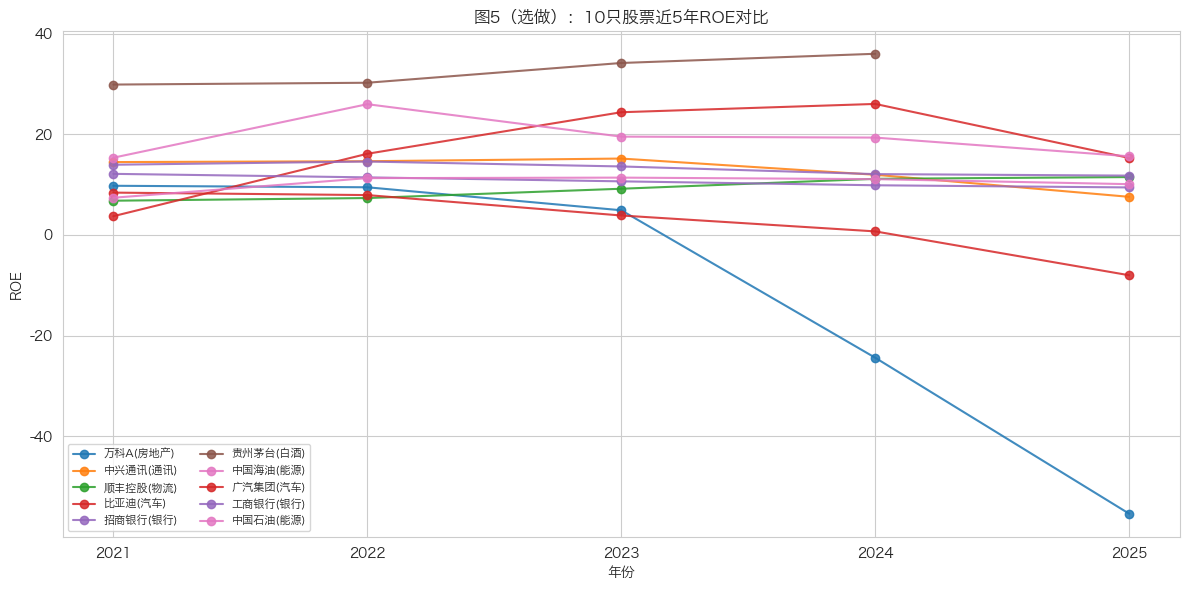

In [10]:
fin = pd.read_csv(DATA_DIR / "finance" / "finance_ratios.csv")
fin["code"] = fin["code"].astype(str).str.zfill(6)
fin["year"] = fin["year"].astype(str)
fin["value"] = pd.to_numeric(fin["value"], errors="coerce")

roe = fin[fin["indicator"] == "roe"].dropna(subset=["value"]).copy()
roe = roe.merge(stock_info[["code", "name", "industry"]], on="code", how="left")

fig, ax = plt.subplots(figsize=(12, 6))
for code, g in roe.groupby("code"):
    g = g.sort_values("year")
    ind = g["industry"].iloc[0] if "industry" in g.columns else "未知"
    ax.plot(g["year"], g["value"], marker="o", linewidth=1.5,
            color=industry_color.get(ind, "gray"), alpha=0.85,
            label=f"{g['name'].iloc[0]}({ind})")

ax.set_title("图5（选做）：10只股票近5年ROE对比")
ax.set_xlabel("年份")
ax.set_ylabel("ROE")

handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), fontsize=8, ncol=2, loc="best", frameon=True)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig5_roe_compare.png", dpi=180)
plt.show()

图 5 解读（选做）：

- ROE 曲线展示了各公司盈利能力随时间的变化路径，不同行业在资本回报水平和波动性上存在显著差异。
- 相对稳定且较高的 ROE 往往对应更强的盈利质量与经营韧性，但也需结合估值与行业周期综合判断。
- 行业内公司间 ROE 的分化，说明同一行业中企业治理、成本控制与业务结构差异同样关键。
- 数据完整性说明：贵州茅台（600519）2025 年 ROE 在当前数据源中缺失，因此图中该公司仅展示到 2024 年；该缺口来自源数据可得性，不是清洗或绘图过程丢失。

## 第五部分：回归分析

本部分完成 CAPM 日频回归（必做）和宏观指标月频回归（选做），并输出结果表与图。

### 5.1 CAPM 模型估计

模型设定：

$$r_{i,t} - r_f = \alpha_i + \beta_i(r_{m,t} - r_f) + \varepsilon_{i,t}$$

其中 $r_f=0.02/252$。对 10 只股票分别用 OLS 估计，输出 $\hat{\alpha}$、p 值、$\hat{\beta}$、95% CI 和 $R^2$。

,股票,行业,α_hat,α p值,β_hat,95% CI,R^2,n_obs
0,万科A,房地产,-0.0013,0.0084,1.0028,"[0.920, 1.086]",0.2698,1514
1,广汽集团,汽车,-0.0003,0.5276,0.9800,"[0.894, 1.066]",0.2478,1514
2,比亚迪,汽车,0.0012,0.0428,1.2818,"[1.186, 1.378]",0.3110,1514
3,顺丰控股,物流,0.0000,0.9365,0.8780,"[0.803, 0.953]",0.2593,1511
4,贵州茅台,白酒,0.0002,0.5316,0.9772,"[0.922, 1.033]",0.4418,1514
5,中国海油,能源,0.0013,0.0624,0.6289,"[0.507, 0.751]",0.0962,958
6,中国石油,能源,0.0006,0.1623,0.4680,"[0.393, 0.543]",0.0908,1514
7,中兴通讯,通讯,-0.0001,0.9295,1.2441,"[1.149, 1.339]",0.3026,1513
8,工商银行,银行,0.0003,0.2460,0.2225,"[0.180, 0.265]",0.0660,1514
9,招商银行,银行,0.0001,0.6965,0.9049,"[0.846, 0.963]",0.3780,1514


已保存: output/capm_results.csv


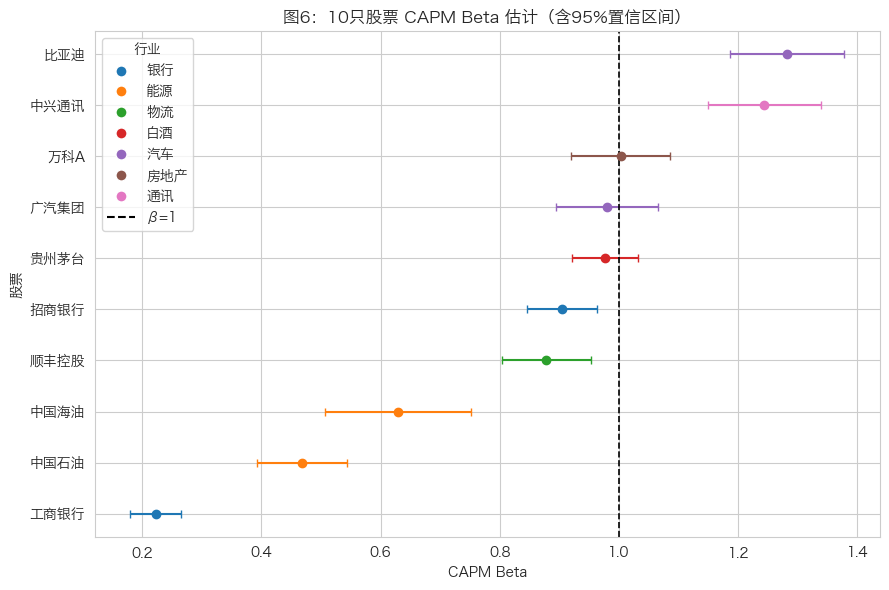

In [12]:
import statsmodels.api as sm

# 市场基准：沪深300日对数收益率
idx300 = pd.read_csv(DATA_DIR / "index" / "index_000300.csv")
idx300["日期"] = pd.to_datetime(idx300["日期"], errors="coerce")
idx300["收盘价"] = pd.to_numeric(idx300["收盘价"], errors="coerce")
idx300 = idx300.dropna(subset=["日期", "收盘价"]).sort_values("日期")
idx300["rm"] = np.log(idx300["收盘价"] / idx300["收盘价"].shift(1))
market_ret = idx300[["日期", "rm"]].dropna().rename(columns={"日期": "date"})

rf_daily = 0.02 / 252
capm_rows = []

for code, g in stock.groupby("code"):
    g = g[["date", "log_ret", "name", "industry"]].dropna(subset=["date", "log_ret"]).copy()
    merged = g.merge(market_ret, on="date", how="inner")
    if merged.empty:
        continue

    y = merged["log_ret"] - rf_daily
    x = merged["rm"] - rf_daily
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    alpha = model.params.get("const", np.nan)
    alpha_p = model.pvalues.get("const", np.nan)
    beta = model.params.get("rm", np.nan)
    beta_l = model.conf_int().loc["rm", 0] if "rm" in model.params.index else np.nan
    beta_u = model.conf_int().loc["rm", 1] if "rm" in model.params.index else np.nan

    capm_rows.append({
        "code": code,
        "股票": merged["name"].iloc[0],
        "行业": merged["industry"].iloc[0],
        "alpha_hat": alpha,
        "alpha_p": alpha_p,
        "beta_hat": beta,
        "beta_ci_low": beta_l,
        "beta_ci_high": beta_u,
        "R^2": model.rsquared,
        "n_obs": int(model.nobs),
    })

capm_df = pd.DataFrame(capm_rows).sort_values(["行业", "股票"]).reset_index(drop=True)
capm_df["95% CI"] = capm_df.apply(lambda r: f"[{r['beta_ci_low']:.3f}, {r['beta_ci_high']:.3f}]", axis=1)

capm_show = capm_df[["股票", "行业", "alpha_hat", "alpha_p", "beta_hat", "95% CI", "R^2", "n_obs"]].copy()
capm_show = capm_show.rename(columns={
    "alpha_hat": "α_hat",
    "alpha_p": "α p值",
    "beta_hat": "β_hat",
})
for c in ["α_hat", "α p值", "β_hat", "R^2"]:
    capm_show[c] = capm_show[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

display(capm_show)
capm_df.to_csv(OUTPUT_DIR / "capm_results.csv", index=False, encoding="utf-8-sig")
print("已保存: output/capm_results.csv")

# Beta系数点图（含95%CI）
plot_df = capm_df.sort_values("beta_hat").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 6))

inds = plot_df["行业"].drop_duplicates().tolist()
palette = sns.color_palette("tab10", n_colors=max(6, len(inds)))
color_map = {ind: palette[i] for i, ind in enumerate(inds)}

for i, row in plot_df.iterrows():
    y_pos = i
    c = color_map[row["行业"]]
    ax.errorbar(
        x=row["beta_hat"],
        y=y_pos,
        xerr=[[row["beta_hat"] - row["beta_ci_low"]], [row["beta_ci_high"] - row["beta_hat"]]],
        fmt="o",
        color=c,
        ecolor=c,
        capsize=3,
        markersize=6,
    )

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, label="β=1")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["股票"].tolist())
ax.set_xlabel("CAPM Beta")
ax.set_ylabel("股票")
ax.set_title("图6：10只股票 CAPM Beta 估计（含95%置信区间）")

from matplotlib.lines import Line2D
legend_items = [Line2D([0], [0], marker="o", color="w", label=k, markerfacecolor=v, markersize=8)
                for k, v in color_map.items()]
legend_items.append(Line2D([0], [0], color="black", linestyle="--", label="β=1"))
ax.legend(handles=legend_items, title="行业", loc="best")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig6_capm_beta.png", dpi=180)
plt.show()

CAPM 结果读取方式说明：

- 第 26 个代码单元仅输出统计量与分组结果（不在代码中直接输出文字结论）。
- 第 27 个 Markdown 单元基于这些统计量给出完整文字分析，便于报告复用与后续维护。

In [13]:
# 分组统计：beta>1、alpha显著、R^2排序
beta_gt1_stats = (
    capm_df.loc[capm_df["beta_hat"] > 1, ["股票", "行业", "beta_hat", "beta_ci_low", "beta_ci_high", "R^2"]]
    .sort_values("beta_hat", ascending=False)
    .reset_index(drop=True)
)

alpha_sig_stats = (
    capm_df.loc[capm_df["alpha_p"] < 0.05, ["股票", "行业", "alpha_hat", "alpha_p", "beta_hat", "R^2"]]
    .sort_values("alpha_p")
    .reset_index(drop=True)
)

r2_rank = (
    capm_df[["股票", "行业", "R^2", "beta_hat", "alpha_hat", "alpha_p"]]
    .sort_values("R^2", ascending=False)
    .reset_index(drop=True)
)

capm_key_stats = pd.DataFrame([
    {"metric": "n_total_stocks", "value": int(capm_df.shape[0])},
    {"metric": "n_beta_gt_1", "value": int((capm_df["beta_hat"] > 1).sum())},
    {"metric": "n_alpha_sig_5pct", "value": int((capm_df["alpha_p"] < 0.05).sum())},
    {"metric": "max_R_squared_stock", "value": r2_rank.loc[0, "股票"]},
    {"metric": "max_R_squared_value", "value": float(r2_rank.loc[0, "R^2"])},
    {"metric": "min_R_squared_stock", "value": r2_rank.loc[r2_rank.index[-1], "股票"]},
    {"metric": "min_R_squared_value", "value": float(r2_rank.loc[r2_rank.index[-1], "R^2"])}
])

display(capm_key_stats)
display(beta_gt1_stats)
display(alpha_sig_stats)
display(r2_rank)

capm_key_stats.to_csv(OUTPUT_DIR / "capm_key_stats.csv", index=False, encoding="utf-8-sig")
print("saved: output/capm_key_stats.csv")

,metric,value
0,n_total_stocks,10
1,n_beta_gt_1,3
2,n_alpha_sig_5pct,2
3,max_R_squared_stock,贵州茅台
4,max_R_squared_value,0.441798
5,min_R_squared_stock,工商银行
6,min_R_squared_value,0.066028


,股票,行业,beta_hat,beta_ci_low,beta_ci_high,R^2
0,比亚迪,汽车,1.281757,1.185528,1.377986,0.311049
1,中兴通讯,通讯,1.244054,1.148760,1.339349,0.302641
2,万科A,房地产,1.002830,0.919600,1.086060,0.269769


,股票,行业,alpha_hat,alpha_p,beta_hat,R^2
0,万科A,房地产,-0.001328,0.008448,1.002830,0.269769
1,比亚迪,汽车,0.001180,0.042804,1.281757,0.311049


,股票,行业,R^2,beta_hat,alpha_hat,alpha_p
0,贵州茅台,白酒,0.441798,0.977216,0.000210,0.531613
1,招商银行,银行,0.378006,0.904907,0.000138,0.696506
2,比亚迪,汽车,0.311049,1.281757,0.001180,0.042804
3,中兴通讯,通讯,0.302641,1.244054,-0.000051,0.929464
4,万科A,房地产,0.269769,1.002830,-0.001328,0.008448
5,顺丰控股,物流,0.259278,0.877961,0.000036,0.936492
6,广汽集团,汽车,0.247800,0.980023,-0.000329,0.527621
7,中国海油,能源,0.096181,0.628909,0.001270,0.062375
8,中国石油,能源,0.090816,0.468041,0.000632,0.162257
9,工商银行,银行,0.066028,0.222470,0.000296,0.246012


saved: output/capm_key_stats.csv


CAPM 详细结果分析：

1. 关于 $\hat{\beta}>1$ 的股票
- 从统计表看，$\hat{\beta}>1$ 的股票有 3 只：比亚迪（汽车，$\hat{\beta}=1.282$）、中兴通讯（通讯，$\hat{\beta}=1.244$）、万科A（房地产，$\hat{\beta}=1.003$）。
- 这意味着上述股票对市场波动更敏感，其中比亚迪与中兴通讯的“高 Beta”特征更明显；万科A虽然略高于 1，但区间与 1 较接近，更应解读为“接近市场平均敏感度上沿”。
- 行业上，汽车与通讯偏周期属性、受景气与风险偏好影响更直接，与较高 Beta 的经验认知总体一致。

2. 关于 $\hat{\alpha}$ 的显著性
- 在 5% 显著性水平下，只有万科A（$p=0.008$）与比亚迪（$p=0.043$）的 alpha 显著异于 0，其余样本均不显著。
- Alpha 显著通常表示：在控制市场超额收益后，该股票仍存在统计上可识别的平均超额收益（或负超额收益）成分，提示 CAPM 单因子并未完全解释其收益过程。
- 但需注意，显著 alpha 不自动等于“稳定可套利能力”，也可能来自阶段性行业冲击、样本区间特异性或遗漏因子（规模、价值、动量等）。

3. 关于 $R^2$ 的高低差异（`R2` 即 $R^2$ 决定系数）
- $R^2$ 最高的是贵州茅台（0.442），其次招商银行（0.378）与比亚迪（0.311）；最低的是工商银行（0.066）与中国石油（0.091）附近。
- 高 $R^2$ 表示市场因子对该股超额收益解释力更强，收益更“市场化”；低 $R^2$ 则说明非市场因素（行业政策、商品价格、公司事件、资产负债结构变化等）占比更高。
- 因此，CAPM 在不同股票上的拟合能力存在显著异质性：可作为基准框架，但在低 $R^2$ 个股上应结合多因子模型做稳健性补充。

### 5.2 宏观指标对股票收益率的影响（选做）

选取月度 CPI 同比作为宏观指标 $X_t$，对 10 只股票分别估计：

$$r_{i,t}^{月} = \alpha_i + \gamma_i X_t + \varepsilon_{i,t}$$

并汇总 $\hat{\gamma}$、p 值、95% CI 与 $R^2$。

,股票,行业,γ_hat,γ p值,95% CI,R^2,n_obs
0,万科A,房地产,0.0045,0.6524,"[-0.0152, 0.0242]",0.0031,67
1,广汽集团,汽车,0.0014,0.8880,"[-0.0178, 0.0206]",0.0003,67
2,比亚迪,汽车,0.0079,0.4989,"[-0.0152, 0.0309]",0.0071,67
3,顺丰控股,物流,0.0180,0.0592,"[-0.0007, 0.0367]",0.0537,67
4,贵州茅台,白酒,0.0063,0.4290,"[-0.0096, 0.0223]",0.0097,67
5,中国海油,能源,-0.0058,0.6268,"[-0.0297, 0.0181]",0.0063,40
6,中国石油,能源,-0.0134,0.0744,"[-0.0282, 0.0014]",0.0482,67
7,中兴通讯,通讯,0.0005,0.9641,"[-0.0211, 0.0221]",0.0000,67
8,工商银行,银行,-0.0102,0.0013,"[-0.0162, -0.0041]",0.1473,67
9,招商银行,银行,-0.0099,0.1888,"[-0.0249, 0.0050]",0.0264,67


已保存: output/macro_gamma_results.csv


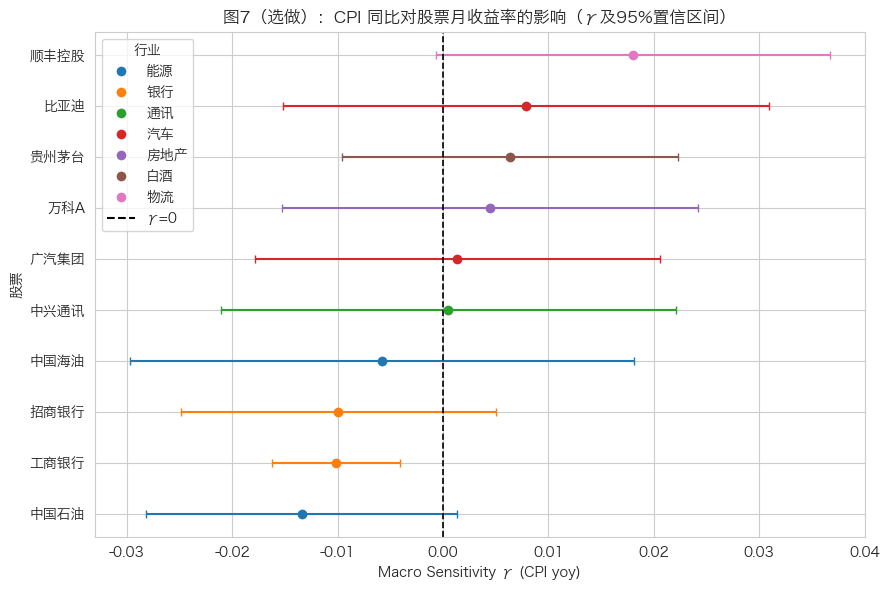

In [14]:
# 准备月度CPI数据（兼容列名）
cpi = pd.read_csv(DATA_DIR / "macro" / "macro_cpi.csv")
date_col = next((c for c in ["日期", "date", "月份", "时间"] if c in cpi.columns), None)
val_col = next((c for c in ["同比", "今值", "cpi_yoy", "value"] if c in cpi.columns), None)
if date_col is None or val_col is None:
    raise ValueError(f"macro_cpi.csv 列名不匹配，当前列: {list(cpi.columns)}")

cpi[date_col] = pd.to_datetime(cpi[date_col], errors="coerce")
cpi[val_col] = pd.to_numeric(cpi[val_col], errors="coerce")
cpi_m = (
    cpi.dropna(subset=[date_col, val_col])
       .set_index(date_col)[val_col]
       .resample("M").last()
       .rename("cpi_yoy")
       .to_frame()
       .reset_index()
       .rename(columns={date_col: "month"})
)

macro_rows = []
for code, g in stock.groupby("code"):
    g = g[["date", "close", "name", "industry"]].dropna(subset=["date", "close"]).sort_values("date")

    monthly_close = (
        g.set_index("date")["close"]
         .resample("M").last()
         .dropna()
    )
    monthly_ret = np.log(monthly_close / monthly_close.shift(1)).dropna().rename("ret_m")
    tmp = monthly_ret.to_frame().reset_index().rename(columns={"date": "month"})
    tmp = tmp.merge(cpi_m, on="month", how="inner").dropna(subset=["ret_m", "cpi_yoy"])

    if len(tmp) < 24:
        continue

    y = tmp["ret_m"]
    X = sm.add_constant(tmp["cpi_yoy"])
    model = sm.OLS(y, X).fit()

    gamma = model.params.get("cpi_yoy", np.nan)
    gamma_p = model.pvalues.get("cpi_yoy", np.nan)
    g_l = model.conf_int().loc["cpi_yoy", 0] if "cpi_yoy" in model.params.index else np.nan
    g_u = model.conf_int().loc["cpi_yoy", 1] if "cpi_yoy" in model.params.index else np.nan

    macro_rows.append({
        "code": code,
        "股票": g["name"].iloc[0],
        "行业": g["industry"].iloc[0],
        "gamma_hat": gamma,
        "gamma_p": gamma_p,
        "gamma_ci_low": g_l,
        "gamma_ci_high": g_u,
        "R^2": model.rsquared,
        "n_obs": int(model.nobs),
    })

macro_df = pd.DataFrame(macro_rows).sort_values(["行业", "股票"]).reset_index(drop=True)
macro_df["95% CI"] = macro_df.apply(lambda r: f"[{r['gamma_ci_low']:.4f}, {r['gamma_ci_high']:.4f}]", axis=1)

macro_show = macro_df[["股票", "行业", "gamma_hat", "gamma_p", "95% CI", "R^2", "n_obs"]].copy()
macro_show = macro_show.rename(columns={"gamma_hat": "γ_hat", "gamma_p": "γ p值"})
for c in ["γ_hat", "γ p值", "R^2"]:
    macro_show[c] = macro_show[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "")

display(macro_show)
macro_df.to_csv(OUTPUT_DIR / "macro_gamma_results.csv", index=False, encoding="utf-8-sig")
print("已保存: output/macro_gamma_results.csv")

# γ点图（含95%CI）
plot_df = macro_df.sort_values("gamma_hat").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 6))

inds = plot_df["行业"].drop_duplicates().tolist()
palette = sns.color_palette("tab10", n_colors=max(6, len(inds)))
color_map = {ind: palette[i] for i, ind in enumerate(inds)}

for i, row in plot_df.iterrows():
    y_pos = i
    c = color_map[row["行业"]]
    ax.errorbar(
        x=row["gamma_hat"],
        y=y_pos,
        xerr=[[row["gamma_hat"] - row["gamma_ci_low"]], [row["gamma_ci_high"] - row["gamma_hat"]]],
        fmt="o",
        color=c,
        ecolor=c,
        capsize=3,
        markersize=6,
    )

ax.axvline(0.0, color="black", linestyle="--", linewidth=1.2, label="γ=0")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df["股票"].tolist())
ax.set_xlabel("Macro Sensitivity γ (CPI yoy)")
ax.set_ylabel("股票")
ax.set_title("图7（选做）：CPI 同比对股票月收益率的影响（γ及95%置信区间）")

from matplotlib.lines import Line2D
legend_items = [Line2D([0], [0], marker="o", color="w", label=k, markerfacecolor=v, markersize=8)
                for k, v in color_map.items()]
legend_items.append(Line2D([0], [0], color="black", linestyle="--", label="γ=0"))
ax.legend(handles=legend_items, title="行业", loc="best")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig7_macro_gamma.png", dpi=180)
plt.show()

In [6]:
sig_df = macro_df[macro_df["gamma_p"] < 0.05]

if sig_df.empty:
    print("在 5% 显著性水平下，未发现对 CPI 同比显著敏感的股票。")
else:
    pairs = [f"{r['股票']}（{r['行业']}，γ={r['gamma_hat']:.4f}, p={r['gamma_p']:.3f}）" for _, r in sig_df.iterrows()]
    print("显著受 CPI 同比影响的股票：")
    print("；".join(pairs))

print("\n行业层面的经济含义（简要）：")
print("1) 对成本端受通胀冲击明显的行业，γ 可能偏负，反映利润率受挤压。")
print("2) 对资源品/上游行业，若具备提价能力，γ 可能偏正。")
print("3) 若 γ 不显著，说明在样本期内个股月收益更多由行业景气和公司特定事件主导。")

显著受 CPI 同比影响的股票：
工商银行（银行，γ=-0.0102, p=0.001）

行业层面的经济含义（简要）：
1) 对成本端受通胀冲击明显的行业，γ 可能偏负，反映利润率受挤压。
2) 对资源品/上游行业，若具备提价能力，γ 可能偏正。
3) 若 γ 不显著，说明在样本期内个股月收益更多由行业景气和公司特定事件主导。


5.2 结果解读（选做）：

- 从系数方向看，CPI 同比对不同行业股票月收益率的影响存在分化：物流（顺丰，$\hat{\gamma}=0.0180$）与汽车（比亚迪，$\hat{\gamma}=0.0079$）偏正，能源与银行整体偏负（如中国石油 $\hat{\gamma}=-0.0134$、工商银行 $\hat{\gamma}=-0.0102$）。这反映了不同行业在通胀环境下的成本传导能力和需求弹性差异。
- 就统计显著性而言，仅工商银行在 5% 水平显著（$p=0.0013$，95% CI 为 $[-0.0162,-0.0041]$，区间完全位于 0 以下），说明 CPI 上行阶段其月收益率更可能受到负向压制。其余股票的置信区间普遍穿过 0，暂不能认定存在稳定线性影响。
- 接近显著但未达阈值的个股主要是顺丰控股（$p=0.059$）和中国石油（$p=0.074$）。这提示两者可能存在方向性关系，但在当前样本长度和噪声水平下，统计证据仍不足，需要扩大样本或引入更多控制变量进一步验证。
- 从解释力度（$R^2$）看，整体数值偏低：多数股票在 0.00-0.05 区间，最高为工商银行（$R^2=0.147$）。这说明“单一宏观变量（CPI）”对个股收益的解释能力有限，个股月度回报仍主要由行业景气、政策冲击、风险偏好和公司特定事件共同驱动。
- 横向比较时还需注意样本可比性：中国海油月度样本数为 40，低于其他股票的 67，置信区间更宽，估计不确定性更高。因此其与其他股票的系数幅度不宜直接做强结论对比。
- 综上，图 7 更适合作为“宏观敏感性筛查”而非因果确认。

## 结论与研究边界

本项目已形成从“数据获取 → 清洗整合 → 描述统计与可视化 → CAPM 回归 → 宏观敏感性回归”的完整分析链条，主要结论如下：

- 描述统计与图表结果显示，不同行业股票在收益波动、分布形态与相关性结构上存在明显异质性，行业属性对风险收益特征有实质影响。
- CAPM 结果表明，市场因子对不同个股的解释力差异显著（$R^2$ 分化明显），说明单因子模型可作为基准，但不足以完整刻画全部收益来源。
- 宏观回归（CPI）显示多数个股系数方向存在行业差异，但显著性整体有限，提示宏观变量对月度收益的影响具有“方向可讨论、强度需谨慎”的特征。

研究边界与注意事项：

- 财务数据来自公开接口，个别公司存在年度缺口（如贵州茅台 2025 年 ROE 缺失），已在图 5 处明确披露。
- 宏观回归为单变量设定，未纳入利率、信用、汇率等潜在共同驱动因素，后续可通过多因子模型与稳健性检验进一步提升解释力。
- 本报告结论用于课程研究与方法演示，不构成任何投资建议。